# Training a Two-Tower Model

In this notebook, we walk through how to build a two-tower recommendation model using PyTorch. The key points:
* Using the **Goodreads** dataset
  * rating: https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv
  * books: https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/books.csv

* Train our model with **negative sampling** via an **InfoNCE** (Information Noise-Contrastive Estimation) objective.
* The source code and knowledge came from the medium blog:
  * [Grokking Two-Tower Models](https://medium.com/@cole.ian.diamond/grokking-two-tower-models-53e0140897e2)
  * [Code](https://colab.research.google.com/drive/1Dhc_i11nuRAm0dRgrD1A3fO_0eBwkv76?usp=sharing)

We evaludate the model using masked Recall@20.

The **two towers** mean:
* A **user** tower which encodes user information into a vector $u$.
* An **item** tower which encodes item information into a vector $v$.


## Two-Tower Model Workflow

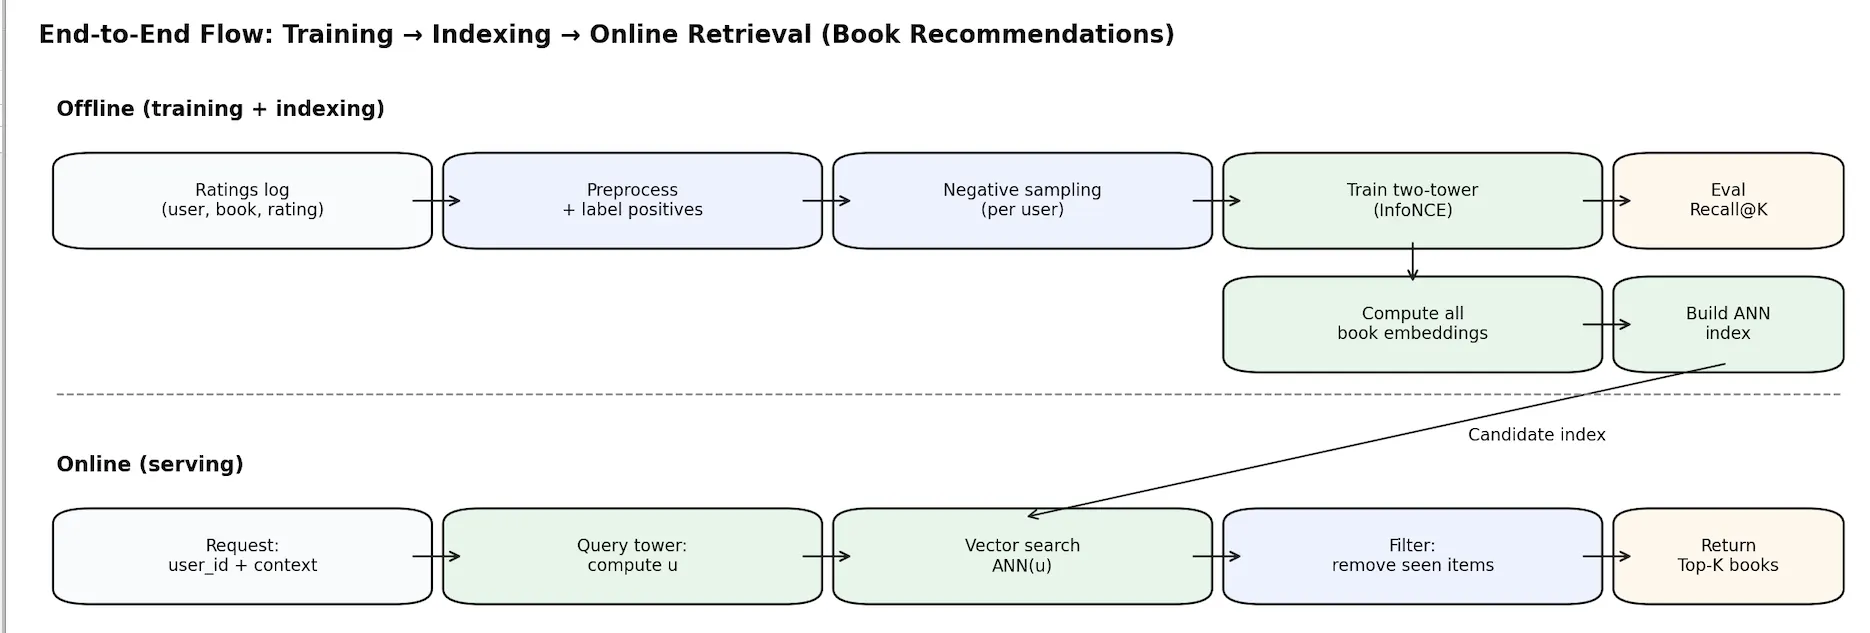


## Recommendation Engine Recap

We can think of the recommendation process as a funnel. In a recommendation engine, usually there are two stages:
1. **Exploration**: This step quickly retrieves similar items but without losing potential recommendation, so usually we choose large k (e.g. k=500). Therefore we optimize **recall** when training two-tower model. We can use Approximate Nearest Neighbor (ANN), not an exact search. We use algorithms like HNSW (Hierarchical Navigable Small Worlds) or IVF-PQ.
2. **Exploitation**: Now we optimzie **precision**. Our goal is filtering from 500 candidates to the final 10. We need to reduce false positves to show users most relevant items; otherwise bringing users' annoyance. This step can be slower and more complex (e.g., a deep Cross-Attention Transformer).

In the following, we focus on two-tower model only.

## Similarity

Given a user $u$, we can retrieve the top (most relevant) K items. The relevance is given by the similarity score, defined as

$$ s(u, v) = \frac{u^{T}v}{\sqrt{d}} + b_u + b_v$$

To recommend, we use nearest-neighbor search: find the items vectors most similar to the user vector.


In [1]:
import torch

# -----------------------------
# Choose device: MPS (Mac), CUDA, or CPU
# -----------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [2]:
import sys
# Update this path to the directory containing model.py
sys.path.append('/content/drive/MyDrive/Colab-Notebooks/Two-Tower/')
!ls /content/drive/MyDrive/Colab-Notebooks/Two-Tower/

ls: cannot access '/content/drive/MyDrive/Colab-Notebooks/Two-Tower/': No such file or directory


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ls /content/drive/MyDrive/data/Two-Tower/

Mounted at /content/drive
books.csv  get_data.py	ratings.csv


In [4]:
import pandas as pd
import numpy as np

print("Downloading ratings...")
ratings = pd.read_csv("/content/drive/MyDrive/data/Two-Tower/ratings.csv")

print("Downloading books...")
books = pd.read_csv("/content/drive/MyDrive/data/Two-Tower/books.csv")

# Quick peek at data shape + a few rows
print("ratings:", ratings.shape)
print("books:", books.shape)

ratings.head()

ratings: (5976479, 3)
books: (10000, 23)


,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [5]:
set(ratings['rating'])

{1, 2, 3, 4, 5}

In [6]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


# Data feature Process

Though the ratings are 1, 2, 3, 4, 5, which can be mapped to a regression task,we also follow the blog [Grokking Two-Tower Models](https://medium.com/@cole.ian.diamond/grokking-two-tower-models-53e0140897e2), converting into a **binary classification** by defining the following simplified binary label:

* 1 if the rating ≥ 4
* 0 otherwise

Meanwhile, we create several categorical features which may aid us in our task to personalize recommendations:

1. **year_bucket**: decade bucket
2. **language_code**: language string (fill missing as "UNK")
3. **primary_author**: first author name


In [7]:
ratings["label"] = ratings.apply(lambda x: 1 if x["rating"] >= 4 else 0, axis=1)
ratings.head()

,user_id,book_id,rating,label
0,1,258,5,1
1,2,4081,4,1
2,2,260,5,1
3,2,9296,5,1
4,2,2318,3,0


In [8]:
book_features = books[["book_id", "original_publication_year", "language_code", "authors"]].copy()
book_features.head()

,book_id,original_publication_year,language_code,authors
0,1,2008.0,eng,Suzanne Collins
1,2,1997.0,eng,"J.K. Rowling, Mary GrandPré"
2,3,2005.0,en-US,Stephenie Meyer
3,4,1960.0,eng,Harper Lee
4,5,1925.0,eng,F. Scott Fitzgerald


## 1. Book Feature: year_bucket

In [9]:
# Ensure publication year is numeric; non-numeric becomes NaN
book_features["original_publication_year"] = pd.to_numeric(book_features["original_publication_year"], errors="coerce")

# and then Bucket year by decade: e.g., 1999 -> 1990, 2003 -> 2000
book_features["year_bucket"] = ((book_features["original_publication_year"] // 10) * 10)

book_features[["original_publication_year", "year_bucket"]].head()

,original_publication_year,year_bucket
0,2008.0,2000.0
1,1997.0,1990.0
2,2005.0,2000.0
3,1960.0,1960.0
4,1925.0,1920.0


## 2. Book Feature: language_code

In [10]:
# Fill missing

book_features["language_code"] = (
    book_features["language_code"]
    .fillna("UNK")
    .astype(str)
    .str.strip()
)
book_features.loc[book_features["language_code"] == "", "language_code"] = "UNK"

## 3. Book Feature: primary_author


In [11]:
# Extract a single "primary author" by taking the first in the comma-separated list

book_features["primary_author"] = book_features.apply(lambda x: x["authors"].strip().split(",")[0], axis=1)
book_features.head()

,book_id,original_publication_year,language_code,authors,year_bucket,primary_author
0,1,2008.0,eng,Suzanne Collins,2000.0,Suzanne Collins
1,2,1997.0,eng,"J.K. Rowling, Mary GrandPré",1990.0,J.K. Rowling
2,3,2005.0,en-US,Stephenie Meyer,2000.0,Stephenie Meyer
3,4,1960.0,eng,Harper Lee,1960.0,Harper Lee
4,5,1925.0,eng,F. Scott Fitzgerald,1920.0,F. Scott Fitzgerald


In [12]:
join_df = ratings.merge(book_features, on="book_id", how="left")
join_df.head()

,user_id,book_id,rating,label,original_publication_year,language_code,authors,year_bucket,primary_author
0,1,258,5,1,2001.0,eng,"Carlos Ruiz Zafón, Lucia Graves",2000.0,Carlos Ruiz Zafón
1,2,4081,4,1,2004.0,en-US,Tom Wolfe,2000.0,Tom Wolfe
2,2,260,5,1,1936.0,eng,Dale Carnegie,1930.0,Dale Carnegie
3,2,9296,5,1,1979.0,en-GB,"Alice Miller, Ruth Ward",1970.0,Alice Miller
4,2,2318,3,0,1995.0,eng,"Thomas J. Stanley, William D. Danko",1990.0,Thomas J. Stanley


## Fill Missing year_bucket

In [13]:
join_df.shape

(5976479, 9)

In [14]:
join_df.dropna().shape

(5970537, 9)

In [15]:
join_df[join_df.isnull().any(axis=1)].head()

,user_id,book_id,rating,label,original_publication_year,language_code,authors,year_bucket,primary_author
2708,158,976,5,1,NaN,UNK,"Robert Kapilow, Dr. Seuss",NaN,Robert Kapilow
13096,543,9197,4,1,NaN,eng,Raymond Chandler,NaN,Raymond Chandler
13853,555,976,4,1,NaN,UNK,"Robert Kapilow, Dr. Seuss",NaN,Robert Kapilow
14622,554,976,5,1,NaN,UNK,"Robert Kapilow, Dr. Seuss",NaN,Robert Kapilow
30609,1044,7646,5,1,NaN,UNK,Gloria Levine,NaN,Gloria Levine


In [16]:
join_df["year_bucket"] = join_df["year_bucket"].fillna(-1).astype(np.int32)

In [17]:
join_df.drop(["original_publication_year"], axis=1).dropna().shape

(5976479, 8)

In [18]:
join_df["user_id"].min(), join_df["book_id"].min()

(1, 1)

## Categorize id Features

In [19]:
join_df["user_id"] = join_df["user_id"].astype("category").cat.codes.astype(np.int64)
join_df["item_id"] = join_df["book_id"].astype("category").cat.codes.astype(np.int64)
join_df["lang_id"] = join_df["language_code"].astype("category").cat.codes.astype(np.int64)
join_df["year_id"] = join_df["year_bucket"].astype("category").cat.codes.astype(np.int64)

author_to_id = {a: i for i, a in enumerate(join_df["primary_author"].unique())}
join_df["author_id"] = join_df["primary_author"].map(author_to_id).astype(np.int64)

join_df.head()

,user_id,book_id,rating,label,original_publication_year,language_code,authors,year_bucket,primary_author,item_id,lang_id,year_id,author_id
0,0,258,5,1,2001.0,eng,"Carlos Ruiz Zafón, Lucia Graves",2000,Carlos Ruiz Zafón,257,7,82,0
1,1,4081,4,1,2004.0,en-US,Tom Wolfe,2000,Tom Wolfe,4080,6,82,1
2,1,260,5,1,1936.0,eng,Dale Carnegie,1930,Dale Carnegie,259,7,75,2
3,1,9296,5,1,1979.0,en-GB,"Alice Miller, Ruth Ward",1970,Alice Miller,9295,5,79,3
4,1,2318,3,0,1995.0,eng,"Thomas J. Stanley, William D. Danko",1990,Thomas J. Stanley,2317,7,81,4


## Statistics Overview

In [20]:
num_users = join_df["user_id"].nunique()
num_items = join_df["item_id"].nunique()
num_langs = join_df["language_code"].nunique()
num_authors = join_df["primary_author"].nunique()
num_year_buckets = join_df["year_bucket"].nunique()
num_interactions = len(join_df)

positives = (join_df["label"] == 1).sum()
positive_rate = (join_df["label"] == 1).mean()

unique_user_ids = join_df["user_id"].nunique()
unique_item_ids = join_df["item_id"].nunique()

# --- build stats dict + DataFrame ---
stats = {
    "num_users": num_users,
    "num_items": num_items,
    "num_languages": num_langs,
    "num_authors": num_authors,
    "num_year_buckets": num_year_buckets,
    "num_interactions": num_interactions,
    "positives": positives,
    "positive_rate": positive_rate,
    "unique_user_ids": unique_user_ids,
    "unique_item_ids": unique_item_ids,
}

stats_df = pd.DataFrame(stats, index=["value"]).T.astype(str)

# --- pretty formatting ---
for col in set(stats.keys()).difference({"positive_rate"}):
    stats_df.loc[col, "value"] = f"{stats[col]:,}"
stats_df.loc["positive_rate", "value"] = f"{positive_rate:.3f}"

display(stats_df)

,value
num_users,"53,424"
num_items,"10,000"
num_languages,26
num_authors,"3,888"
num_year_buckets,84
num_interactions,"5,976,479"
positives,"4,122,111"
positive_rate,0.690
unique_user_ids,"53,424"
unique_item_ids,"10,000"


# Training Model

## Training/Validation/Test Split

In [21]:
from sklearn.model_selection import train_test_split

seed = 42

# Create training set (80% of data)
train_df, temp_df = train_test_split(
    join_df,
    test_size=0.2,
    random_state=seed,
)

# Create validation and testing set from equal halves of the remaining 20% of data
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=seed,
)

print(f"training size: {len(train_df)}, val size: {len(val_df)}, test size: {len(test_df)}")

training size: 4781183, val size: 597648, test size: 597648


# Negative sampling

In retrieval, we want each training example to contain one positive and several negatives. We train on uniformly sampled negatives since treating every missing interaction as a true negative is intractable.

For each positive (user, book) pair, we sample N negatives from books the user did not positively interact with.


In [22]:
# -----------------------------
# Build training positives and user -> pos lookup
# -----------------------------
train_pos_df = train_df[train_df["label"] == 1].copy()

In [23]:
train_df.shape, train_pos_df.shape

((4781183, 13), (3297296, 13))

In [24]:
# Map each user to the set of items they liked in training
user_to_train_pos = (
    train_pos_df.groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)

In [25]:
# Create dataset and loader
num_items = int(join_df["item_id"].nunique())
print(num_items)

10000


## Dataloader (batch size=1024)

In [26]:
from torch.utils.data import Dataset, DataLoader
from dataloader import GoodreadsData

train_dataset = GoodreadsData(
    df_pos=train_pos_df,
    user_to_pos_set=user_to_train_pos,
    num_items=num_items,
    num_neg=10,   # negative sampling, typically 5–20
    seed=42,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True,
    drop_last=True,  # stable batch shapes
    num_workers=0,   # use 0 for notebook simplicity; increase for speed
)

# Sanity check a batch
batch = next(iter(train_loader))
print({k: v.shape for k, v in batch.items()})
print({k: v.dtype for k, v in batch.items()})


{'user_id': torch.Size([1024]), 'pos_item_id': torch.Size([1024]), 'neg_item_id': torch.Size([1024, 10])}
{'user_id': torch.int64, 'pos_item_id': torch.int64, 'neg_item_id': torch.int64}


# Model architecture

## User tower
The simplest user tower is an embedding lookup:

$$u = \textrm{UserEncoder(user_id)} \in R^D$$

The network learns a dense vector u summarizing a user’s preferences. Users with lots of history get very good embeddings.

## Item tower

Here, we combine a book ID embedding with a feature-based embedding built from metadata (language, year bucket, author). One pattern is:

$$ v = v_{id} + v_{fe}, $$

$v_{fe}$ offers us a useful cold start lever: even if a specific book has little training data, its metadata can still place it in a meaningful region of embedding space.

Intuitively, books sharing an author or language may be comparable.


## Bias Terms

Bias terms absorb global popularity effects and user activity levels, allowing the embeddings to focus on a personalized signal:
* Some users interact with many items (high a**ctivity**) $ \to b_u$.
* Some items are broadly appealing (high **popularity**) $\to b_i$.

## Loss Function: InfoNCE

InfoNCE is also known as Sampled softmax.

**InfoNCE** (Information Noise-Contrastive Estimation) is a widely used loss function in self-supervised learning and contrastive learning. It trains models to identify a positive sample among multiple negative samples. The model learns effective representations by bringing positive pairs together in embedding space while pushing negative samples away.

InfoNCE loss for one training example $u$ is

$$p(i^+|u) = \frac{\exp{(s^+/\tau)}}{\exp{(s^+/\tau)}+\sum_j \exp{(s_j^-/\tau)}},$$

a candidate set with one positive and N negatives. Here we used $N=10$.

It utilizes a **categorical cross-entropy loss** to classify the positive sample correctly. In the implementation level, it is commonly used with a temperature parameter $\tau$ to scale similarity scores and control sensitivity.

A smaller $\tau$ makes the loss focus harder on the toughest negatives, amplifying the loss; larger $\tau$ smooths gradients. It is recommended to start with $\tau = 1$.



## A Training Loop

Again, the goal of each batch is to **make the user embedding closer to the positive item embedding than to sampled negative items**.

The training loop is doing:

* One epoch is defined by iterating over batches of user-item interactions with sampled negatives.
* Each batch contains a user ID, one positive item the user interacted with multiple negative items the user did not interact with.
* Item metadata (language, year, author) is joined at training time by indexing into preloaded lookup tensors.
* Computes a **relevance score** for each (user, item) pair using the model's forward pass (typically a dot product plus bias).
* Scores the positive item once per user to obtain $s^+$.
* Scores all negative items in a single vectorized pass by expanding user IDs to match the negative item tensor shape.
* Constructs a candidate set per user consisting of index 0 is the positive items; indices $1, \cdots N$ are negative samples.
* Applies temperature scaling to control the sharpness of the softmax and gradient magnitude.
* Uses cross-entropy loss as InfoNCE / sampled softmax, where the model is trained to classify the positive item (index 0) among all candidates.
* Encourages relative ranking, not absolute scores — the loss only cares that the positive scores higher than negatives.
* Backpropagates through both towers simultaneously, updating user embeddings, item embeddings, and metadata embeddings together.
* Performs one optimizer step per batch, accumulating loss.
* Learns an embedding space directly optimized for top-K retrieval, which can later be indexed with ANN methods (FAISS / ScaNN) in production.


In [27]:
import torch.nn.functional as F

def train(
    model,
    dataloader,
    optimizer,
    device,
    item_lang_ids,      # [num_items]
    item_year_ids,      # [num_items]
    item_author_ids,    # [num_items]
    info_nce=True,
    temperature=1.0,
):
    """
    Train for one epoch.

    For each batch:
      - compute s_pos for (u, pos_item)
      - compute s_neg for (u, neg_items)
      - InfoNCE: cross-entropy over [s_pos, s_neg...]
    """
    model.train()

    total_loss = 0.0
    steps = 0

    # Move item metadata tensors to device once
    item_lang_ids = item_lang_ids.to(device)
    item_year_ids = item_year_ids.to(device)
    item_author_ids = item_author_ids.to(device)

    for batch in dataloader:
        # Batch tensors
        u = batch["user_id"].to(device)           # [B]
        i_pos = batch["pos_item_id"].to(device)   # [B]
        i_neg = batch["neg_item_id"].to(device)   # [B, Nneg]

        # Lookup metadata ids for positive items
        pos_language   = item_lang_ids[i_pos]         # [B]
        pos_year   = item_year_ids[i_pos]         # [B]
        pos_author = item_author_ids[i_pos]       # [B]

        # Lookup metadata ids for negative items
        neg_lang   = item_lang_ids[i_neg]         # [B, Nneg]
        neg_year   = item_year_ids[i_neg]         # [B, Nneg]
        neg_author = item_author_ids[i_neg]       # [B, Nneg]

        # Clear gradients
        optimizer.zero_grad(set_to_none=True)

        # Positive scores s(u, i_pos): [B]
        s_pos = model(u, i_pos, pos_language, pos_year, pos_author)

        # Expand users to match the negative item tensor shape
        # u_neg: [B, Nneg]
        u_neg = u.unsqueeze(1).expand_as(i_neg)

        # Negative scores s(u, i_neg): [B, Nneg]
        s_neg = model(u_neg, i_neg, neg_lang, neg_year, neg_author)

        # InfoNCE / sampled softmax:
        # candidates scores: [B, 1 + Nneg], label is 0 (positive at index 0)
        scores = torch.cat([s_pos.unsqueeze(1), s_neg], dim=1)  # [B, 1+Nneg]
        scores = scores / temperature                           # optional sharpening
        targets = torch.zeros(scores.size(0), dtype=torch.long, device=device)
        loss = F.cross_entropy(scores, targets)

        # Backprop + optimizer step
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        steps += 1

    return total_loss / max(steps, 1)


## Evaluation: Masked Recall@K

In [28]:
@torch.no_grad()
def recall_at_k_mask_seen(
    model,
    eval_pos,            # dict: user -> set of held-out positive items
    train_seen,          # dict: user -> set of training-seen items to mask
    num_items,
    item_lang_ids,       # torch tensor of shape [num_items]
    item_year_ids,       # torch tensor of shape [num_items]
    item_author_ids,     # torch tensor of shape [num_items]
    K=20,
    device="cpu",
    max_users=None,
):
    """
    Compute average per-user Recall@K with masking of items seen in training.

    Steps per user:
      - Score all items
      - Mask train_seen items (set their scores to -inf)
      - Take top-K
      - Recall = hits_in_topK / num_heldout_positives
    """
    model.eval()

    # Move item metadata tensors to device once
    item_lang_ids = item_lang_ids.to(device)
    item_year_ids = item_year_ids.to(device)
    item_author_ids = item_author_ids.to(device)

    # All item ids [0..num_items-1]
    all_item_ids = torch.arange(num_items, device=device, dtype=torch.long)

    # Precompute all item embeddings and biases (fast for repeated user scoring)
    all_item_embs = model.encode_item(
        all_item_ids,
        item_lang_ids,
        item_year_ids,
        item_author_ids
    )  # [I, D]
    all_item_bias = model.item_bias(all_item_ids).squeeze(-1)  # [I]

    # User list to evaluate
    users = list(eval_pos.keys())
    if max_users is not None:
        users = users[:max_users]

    recalls = []

    for u in users:
        # Held-out positives for this user
        pos_set = eval_pos.get(u, set())
        if not pos_set:
            continue

        # Compute user embedding + bias
        user_id = torch.tensor([u], device=device, dtype=torch.long)
        user_emb = model.encode_user(user_id)                # [1, D]
        user_b   = model.user_bias(user_id).squeeze(-1)      # [1]

        # Dot-product scores for all items: [I]
        scores = (user_emb @ all_item_embs.T).squeeze(0) / model.scale

        # Add item biases and user bias
        scores = scores + all_item_bias + user_b

        # Mask training-seen items so we don’t “recommend” what they already consumed
        seen = train_seen.get(u, set())
        if seen:
            seen_idx = torch.tensor(list(seen), device=device, dtype=torch.long)
            scores[seen_idx] = -1e9

        # Top-K predicted item ids
        topk = torch.topk(scores, K, largest=True).indices.tolist()

        # Count hits among held-out positives
        hits = sum((i in pos_set) for i in topk)
        recalls.append(hits / len(pos_set))

    # Average recall across users
    return float(sum(recalls) / len(recalls)) if recalls else 0.0

In [29]:
# -----------------------------
# Build item-level metadata tensors aligned to item_idx
# -----------------------------
# We need a single row per item_idx containing its lang/year/author indices.
item_meta = (
    join_df[["item_id", "lang_id", "year_id", "author_id"]]
    .drop_duplicates("item_id")
    .sort_values("item_id")
)
item_meta.shape

(10000, 4)

In [30]:
num_items

10000

In [31]:
len(set(item_meta['item_id']))

10000

In [32]:
# Convert metadata columns into torch tensors of shape [num_items]
item_lang_ids   = torch.tensor(item_meta["lang_id"].values, dtype=torch.long)
item_year_ids   = torch.tensor(item_meta["year_id"].values, dtype=torch.long)
item_author_ids = torch.tensor(item_meta["author_id"].values, dtype=torch.long)

# Cardinalities
num_users = int(join_df["user_id"].nunique())
num_items = int(join_df["item_id"].nunique())
num_langs = int(join_df["lang_id"].nunique())
num_year_buckets = int(join_df["year_id"].nunique())
num_authors = int(join_df["author_id"].nunique())

# Sanity checks: item_meta should be exactly one row per item, and ordered 0..num_items-1
assert len(item_meta) == num_items
assert (item_meta["item_id"].values == torch.arange(num_items).numpy()).all()


In [33]:
# -----------------------------
# Build train_seen (mask set) and eval_pos (held-out positives)
# -----------------------------
train_seen = (
    train_df.groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)

In [34]:
# Evaluate on validation set during training
eval_df = val_df

# Held-out positives per user in eval split
eval_pos = (
    eval_df[eval_df["label"] == 1]
    .groupby("user_id")["item_id"]
    .apply(set)
    .to_dict()
)

print(f"train users: {len(train_seen)}, eval users: {len(eval_pos)}")

train users: 53424, eval users: 53028


In [35]:
from model import TwoTowerModel

# -----------------------------
# Initialize model + optimizer
# -----------------------------
model = TwoTowerModel(
    num_users=num_users,
    num_items=num_items,
    num_langs=num_langs,
    num_year_buckets=num_year_buckets,
    num_authors=num_authors,
    emb_dim=64,
).to(device)

print(f"num_users: {num_users}, num_items: {num_items}, num_langs: {num_langs}, num_year_buckets: {num_year_buckets}, num_authors: {num_authors}")

# Adam with mild weight decay (L2 regularization)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


Using device: cuda
num_users: 53424, num_items: 10000, num_langs: 26, num_year_buckets: 84, num_authors: 3888


## Sanity Check Before Training

In [36]:
# Check ALL vocab sizes
checks = [
    ("Users", train_df['user_id'].max(), num_users),
    ("Items", train_df['item_id'].max(), num_items),
    ("Langs", train_df['lang_id'].max(), num_langs),
    ("Years", train_df['year_id'].max(), num_year_buckets),
    ("Authors", train_df['author_id'].max(), num_authors)
]

for name, max_id, vocab in checks:
    print(f"{name}: Max ID {max_id}, Vocab {vocab}")
    if max_id >= vocab:
        print(f"!!! CRITICAL ERROR: {name} ID {max_id} is out of bounds for vocab {vocab}")

Users: Max ID 53423, Vocab 53424
Items: Max ID 9999, Vocab 10000
Langs: Max ID 25, Vocab 26
Years: Max ID 83, Vocab 84
Authors: Max ID 3887, Vocab 3888


## Training Model

In [37]:
# -----------------------------
# Train loop
# -----------------------------
num_epochs = 10
losses = []
recall20s = []

for epoch in range(1, num_epochs + 1):
    # Train one epoch
    loss = train(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        item_lang_ids=item_lang_ids,
        item_year_ids=item_year_ids,
        item_author_ids=item_author_ids,
        info_nce=True,         # sampled softmax
        temperature=1.0,       # can tune
    )

    # Evaluate masked recall@20
    r20 = recall_at_k_mask_seen(
        model=model,
        eval_pos=eval_pos,
        train_seen=train_seen,
        num_items=num_items,
        item_lang_ids=item_lang_ids,
        item_year_ids=item_year_ids,
        item_author_ids=item_author_ids,
        K=20,
        device=device,
        max_users=2000,        # cap for speed; set None for full eval
    )

    losses.append(loss)
    recall20s.append(r20)

    print(f"Epoch {epoch:02d} | loss: {loss:.4f} | masked recall@20: {r20:.4f}")


Epoch 01 | loss: 2.0736 | masked recall@20: 0.0796
Epoch 02 | loss: 1.4917 | masked recall@20: 0.1007
Epoch 03 | loss: 1.1950 | masked recall@20: 0.1163
Epoch 04 | loss: 1.0708 | masked recall@20: 0.1210
Epoch 05 | loss: 1.0333 | masked recall@20: 0.1243
Epoch 06 | loss: 1.0079 | masked recall@20: 0.1236
Epoch 07 | loss: 0.9887 | masked recall@20: 0.1207
Epoch 08 | loss: 0.9746 | masked recall@20: 0.1228
Epoch 09 | loss: 0.9645 | masked recall@20: 0.1244
Epoch 10 | loss: 0.9591 | masked recall@20: 0.1282


## Visualize Training Loss and Masked Recall

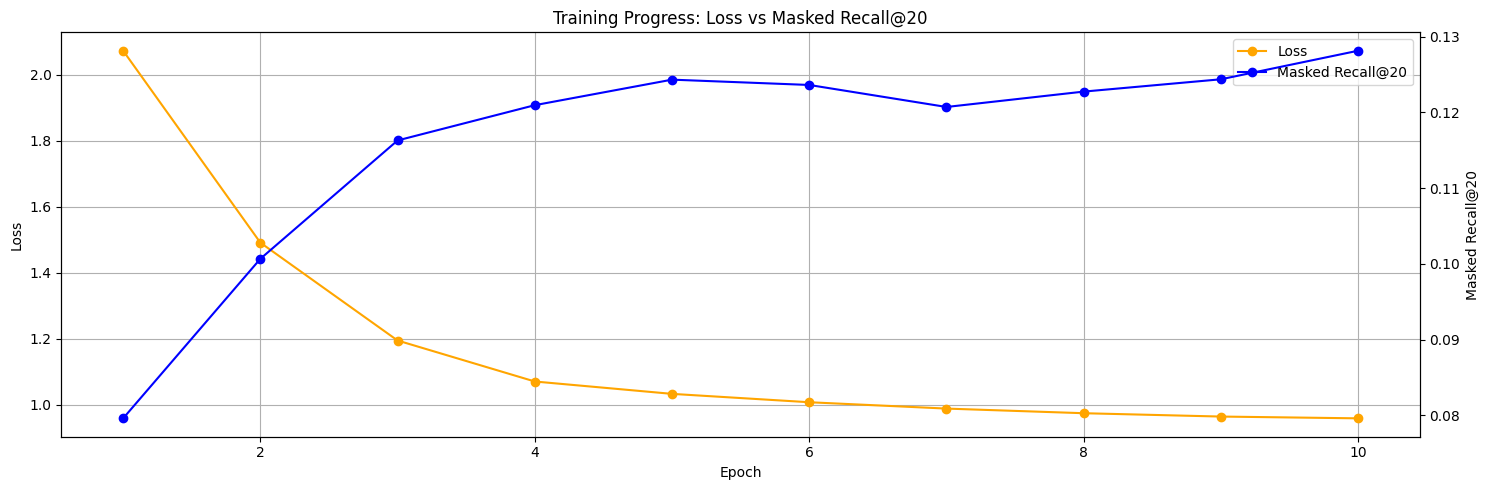

In [39]:
# -----------------------------
# Plot loss vs masked recall@20
# -----------------------------
import matplotlib.pyplot as plt

epochs = list(range(1, num_epochs + 1))

fig, ax1 = plt.subplots(figsize=(15, 5))

# Left axis: loss
ax1.plot(epochs, losses, marker="o", label="Loss", color="orange")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

# Right axis: recall@20
ax2 = ax1.twinx()
ax2.plot(epochs, recall20s, marker="o", label="Masked Recall@20", color="blue")
ax2.set_ylabel("Masked Recall@20")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("Training Progress: Loss vs Masked Recall@20")
plt.tight_layout()
plt.show()

## Inspect Recommendation

In [40]:
import numpy as np
import torch

@torch.no_grad()
def inspect_5_users(
    model,
    train_df,
    eval_df,                 # val_df or test_df
    item_info,               # from above
    item_lang_ids,           # torch.LongTensor [num_items]
    item_year_ids,           # torch.LongTensor [num_items]
    item_author_ids,         # torch.LongTensor [num_items]
    num_items,
    K=10,
    n_users=5,
    device="cpu",
    seed=42,
):
    model.eval()

    train_pos = (
        train_df[train_df["label"] == 1]
        .groupby("user_id")["item_id"]
        .apply(set)
        .to_dict()
    )
    eval_pos = (
        eval_df[eval_df["label"] == 1]
        .groupby("user_id")["item_id"]
        .apply(set)
        .to_dict()
    )

    users = list(eval_pos.keys())
    if not users:
        print("No eval positives to inspect.")
        return

    rng = np.random.default_rng(seed)
    chosen = rng.choice(users, size=min(n_users, len(users)), replace=False).tolist()

    # Precompute all item embeddings once
    item_lang_ids = item_lang_ids.to(device)
    item_year_ids = item_year_ids.to(device)
    item_author_ids = item_author_ids.to(device)
    all_item_ids = torch.arange(num_items, device=device, dtype=torch.long)
    all_item_embs = model.encode_item(all_item_ids, item_lang_ids, item_year_ids, item_author_ids)  # [I, D]

    info = item_info.set_index("item_id")

    def fmt(i):
        r = info.loc[i]
        return f'{int(r.book_id)} | {str(r.title)[:80]} | lang={r.language_code} | year_bucket={r.year_bucket}'

    for u in chosen:
        seen = train_pos.get(u, set())
        held = eval_pos.get(u, set())

        user_id = torch.tensor([u], device=device, dtype=torch.long)
        user_emb = model.encode_user(user_id)  # [1,D]

        scores = (user_emb @ all_item_embs.T).squeeze(0) / model.scale

        # mask train-seen
        if seen:
            scores[torch.tensor(list(seen), device=device, dtype=torch.long)] = -1e9

        topk = torch.topk(scores, K, largest=True).indices.detach().cpu().tolist()
        hits = [i for i in topk if i in held]

        print("\n" + "="*100)
        print(f"user_idx={u} | train_pos={len(seen)} | eval_pos={len(held)} | hits_in_top{K}={len(hits)}")

        print("\nTrain history (first 15 positives):")
        for i in list(seen)[:15]:
            print("  H ", fmt(i))

        print(f"\nTop-{K} recommendations (masked train-seen):")
        for rank, i in enumerate(topk, 1):
            mark = "✅" if i in held else "  "
            print(f"  {mark} #{rank:02d} {fmt(i)}")

        print("\nHeld-out eval positives (first 15):")
        for i in list(held)[:15]:
            print("  T ", fmt(i))

    print("\nDone.")


# Map item_idx -> (book_id, title, language_code, year_bucket)
item_info = (
    join_df[["item_id", "book_id", "language_code", "year_bucket", "primary_author"]]
    .drop_duplicates("item_id")
    .merge(books[["book_id", "title"]], on="book_id", how="left")
    .sort_values("item_id")
)

inspect_5_users(
    model=model,
    train_df=train_df,
    eval_df=val_df,              # or test_df
    item_info=item_info,
    item_lang_ids=item_lang_ids,
    item_year_ids=item_year_ids,
    item_author_ids=item_author_ids,
    num_items=num_items,
    K=10,
    n_users=5,
    device=device,
    seed=42,
)


user_idx=41322 | train_pos=59 | eval_pos=11 | hits_in_top10=2

Train history (first 15 positives):
  H  9601 | Superman: Whatever Happened to the Man of Tomorrow? | lang=eng | year_bucket=1980
  H  7299 | All-Star Superman, Vol. 2 | lang=eng | year_bucket=2000
  H  7 | The Hobbit | lang=en-US | year_bucket=1930
  H  5128 | Lunar Park | lang=UNK | year_bucket=2000
  H  1422 | Out from Boneville (Bone, #1) | lang=eng | year_bucket=1990
  H  4494 | Y: The Last Man, Vol. 8: Kimono Dragons (Y: The Last Man, #8) | lang=eng | year_bucket=2000
  H  19 | The Fellowship of the Ring (The Lord of the Rings, #1) | lang=eng | year_bucket=1950
  H  532 | Batman: Year One | lang=eng | year_bucket=1980
  H  8214 | Sin City, Vol. 3: The Big Fat Kill (Sin City, #3) | lang=en-US | year_bucket=1990
  H  4507 | Y: The Last Man, Vol. 5: Ring of Truth (Y: The Last Man, #5) | lang=eng | year_bucket=2000
  H  3995 | Sin City, Vol. 4: That Yellow Bastard (Sin City, #4) | lang=eng | year_bucket=1990
  H  7580 | 